In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1.Load dataset

In [17]:
df = pd.read_csv('../data/churn_cleaned.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend,NumAddOnServices,HasInternet
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1yr,29.850000,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,2-4yr,55.573529,2,1
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1yr,54.075000,2,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr,40.905556,3,1
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1yr,75.825000,0,1


# 2.Train-Test split

In [3]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5625, 23)  Test: (1407, 23)


# 3.Preprocessing Pipeline

In [4]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])
print(f"{len(numeric_features)} numeric, {len(categorical_features)} categorical features")

7 numeric, 16 categorical features


C:\Users\souvi\AppData\Local\Temp\ipykernel_9776\2215622125.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


# 4. Compare baseline models (5-fold cross-validated ROC-AUC)

In [5]:
# Handle class imbalance for the boosting models.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=320,
        max_depth=-1,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        objective="binary",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores.mean()
    print(f"{name}: ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

best_name = max(results, key=results.get)
print("\nBest baseline model:", best_name)

LogisticRegression: ROC-AUC = 0.8477 +/- 0.0133
RandomForest: ROC-AUC = 0.8438 +/- 0.0116
GradientBoosting: ROC-AUC = 0.8481 +/- 0.0125
XGBoost: ROC-AUC = 0.8447 +/- 0.0124
LightGBM: ROC-AUC = 0.8368 +/- 0.0087

Best baseline model: GradientBoosting


# 5. Hyperparameter tuning (best model)

In [6]:
from sklearn.model_selection import GridSearchCV

best_clf = models[best_name]
pipe = Pipeline([("preprocess", preprocessor), ("model", best_clf)])

if best_name == "LogisticRegression":
    param_grid = {
        "model__C": [0.01, 0.1, 1, 10]
    }

elif best_name == "RandomForest":
    param_grid = {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", "log2"],
        "model__class_weight": [None, "balanced"]
    }

elif best_name == "GradientBoosting":
    param_grid = {
        "model__n_estimators": [100, 200], 
        "model__learning_rate": [0.05, 0.1], 
        "model__max_depth": [2, 3, 4]
    }

elif best_name == "XGBoost":
    param_grid = {
        "model__n_estimators": [200, 300,400],
        "model__max_depth": [3, 4, 5],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }

else:  # LightGBM
    param_grid = {
        "model__n_estimators": [200, 300,400],
        "model__num_leaves": [15, 31, 63],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [-1, 10, 20]
    }

search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
search.fit(X_train, y_train)

print("Best model:", best_name)
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", round(search.best_score_, 4))

best_model = search.best_estimator_

Best model: GradientBoosting
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 0.8518


# 6. Final evaluation on the held-out test set

In [7]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 score: ", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


Accuracy:  0.7854
Precision: 0.6268
Recall:    0.4759
F1 score:  0.541
ROC-AUC:   0.8343

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



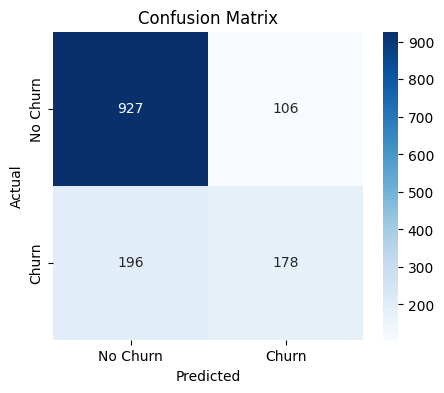

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

In [23]:
from imblearn.combine import SMOTEENN

In [35]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
])

X_sample= pipe.fit_transform(X)

In [37]:
sm = SMOTEENN()
X_resampled, y_resampled = sm.fit_resample(X_sample,y)

In [38]:
Xr_train,Xr_test, yr_train,yr_test = train_test_split(X_resampled,y_resampled,
                                                      test_size=0.2,random_state=42)

In [47]:
model_gb_smote = GradientBoostingClassifier(random_state=42)

In [48]:
model_gb_smote.fit(Xr_train,yr_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [49]:
y_pred_smote = model_gb_smote.predict(Xr_test)

In [50]:
 print(classification_report(yr_test,y_pred_smote,labels=[0,1]))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       565
           1       0.94      0.96      0.95       752

    accuracy                           0.94      1317
   macro avg       0.95      0.94      0.94      1317
weighted avg       0.94      0.94      0.94      1317



In [51]:
print(confusion_matrix(yr_test,y_pred_smote))

[[520  45]
 [ 28 724]]


In [58]:
import pickle

with open("../models/churn_model.pkl", "wb") as file:
    pickle.dump(model_gb_smote, file)

In [59]:
with open("../models/churn_model.pkl", "rb") as f:
    model = pickle.load(f)

In [60]:
model.score(Xr_test,yr_test)

0.9445709946848899